Connection to MariaDB successful!


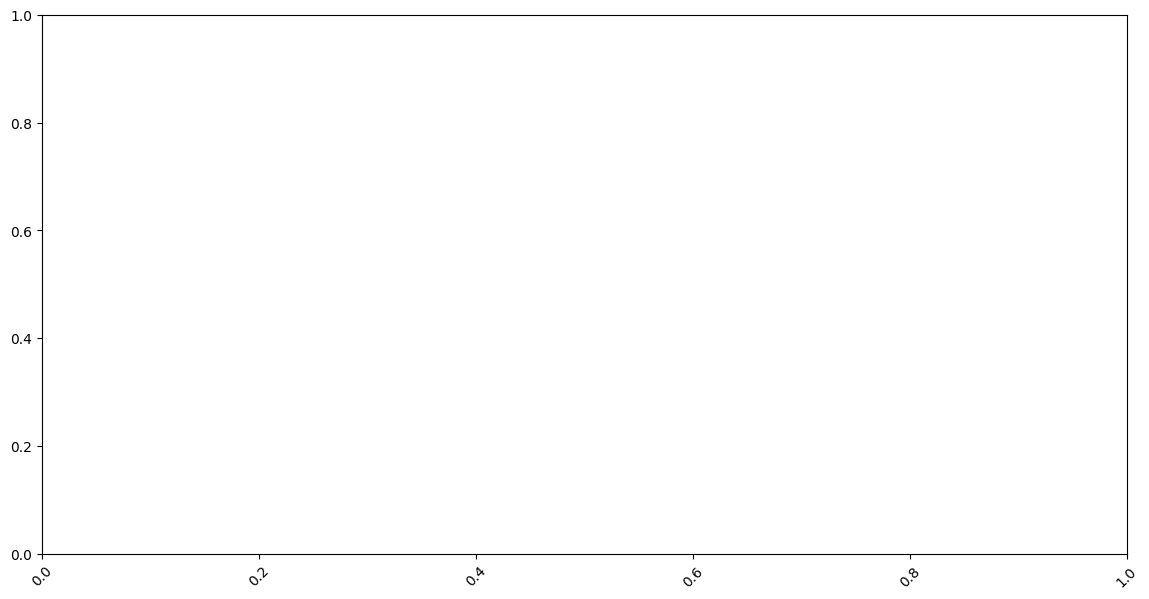

In [2]:
import pandas as pd
import networkx as nx
import random
import matplotlib.pyplot as plt
import numpy as np


from database_tables import engine,Base,sessionmaker
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
import os

Session = sessionmaker(bind=engine)
Base.metadata.create_all(engine)

# Set global font style and size
plt.figure(figsize=(14, 7))
plt.xticks(rotation=45)
plt.rcParams.update({
    'font.family': 'serif',  # Use 'sans-serif' for a modern look
    'font.size': 18,         # Set base font size
    'axes.titlesize': 20,   # Title size
    'axes.labelsize': 20,    # Axis labels size
    'xtick.labelsize': 17,   # X-axis tick labels
    'ytick.labelsize': 17,   # Y-axis tick labels
    'legend.fontsize': 13,   # Legend text size
    'figure.figsize': (14, 7)  # Default size for all figures
})

In [3]:
def analyze(query, best_gamma):
    df = pd.read_sql(query, con=engine)
    df.describe()
    result=df.groupby('lambda_mult').agg(mean_pymetis=('pymetis_inter_edges', 'mean'), mean_inter_edges=('qa_inter_edges', 'mean'),
    mean_kernihanLin=('kernighan_lin_inter_edges','mean')
    ).reset_index()
    print(result)
    # Create a figure and axes
    fig, ax = plt.subplots(figsize=(10, 6))

    # Bar plot for `mean_pymetis`
    ax.plot(result['lambda_mult'], result['mean_pymetis'], color='skyblue',  marker='o', label='Mean PyMetis')

    # Bar plot for `mean_kernighanLin`
    ax.plot(result['lambda_mult'], result['mean_kernihanLin'], color='green',  marker='o', label='Mean KernighanLin')

    # Line plot for `mean_inter_edges`
    ax.plot(result['lambda_mult'], result['mean_inter_edges'], color='orange', marker='o', label='Mean Hybrid')

    # Set axis labels
    ax.set_xlabel('Gamma Coefficient')
    ax.set_ylabel('Values')

    # Set x-axis limits
    ax.set_xlim(0.4, 1.6)

    # Add legends
    ax.legend()

    # Add a title
    plt.title('Mean Delta PyMetis and Mean Inter Edges by Gamma Coefficient')

    # Show the plot
    plt.tight_layout()
    plt.show()

    df0_1=df[df['lambda_mult']==best_gamma]
    result=df0_1.groupby('nr_of_nodes').agg(mean_pymetis=('pymetis', 'mean'), mean_hybrid=('hybrid_inter_edges', 'mean'),mean_kerninghan=('kernighan_lin_inter_edges','mean')).reset_index()
    # Create the plot
    print(result)
    plt.figure(figsize=(10, 6))

    # Plot each metric
    plt.plot(result['nr_of_nodes'], result['mean_pymetis'], label='Mean PyMetis', marker='o', color='blue')
    plt.plot(result['nr_of_nodes'], result['mean_hybrid'], label='Mean Hybrid', marker='s', color='orange')
    plt.plot(result['nr_of_nodes'], result['mean_kerninghan'], label='Mean Kerninghan', marker='^', color='green')

    # Add labels, title, and legend
    plt.xlabel('Number of Nodes (nodes_nr)')
    plt.ylabel('Mean Values')
    plt.title('Comparison of Mean Metrics by Number of Nodes')
    plt.legend()

    # Show the grid and plot
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
        


In [4]:
query_for_regression = """
## graphs with best partitions and min/max gamma
with p0 as (
select g.id as graph_id
from partitions p
inner join graphs g on p.graph_id  = g.id
where nr_of_nodes in (100,200)
#and edge_probability in (0.1, 0.25, 0.5, 0.75)
and g.id > 1045
group by g.id
having sum(round(lambda_total/lambda_est,4)) >= 0.75
union all
select g.id
from partitions p
inner join graphs g on p.graph_id  = g.id
where nr_of_nodes in  (300,400,500,600,700,800,900,1000,1200,1400,1600,1800,2000,2500,3000,4000)
#and edge_probability in (0.1, 0.25, 0.5, 0.75)
and g.id > 1045
group by g.id
having sum(round(lambda_total/lambda_est,4)) >= 0.195 
),
p1 as (
select min(p.qa_inter_edges) as min_edges,
	p.graph_id
from p0 
inner join partitions p on p.graph_id = p0.graph_id
where 1=1 
and p.comp_type = "hybrid"
and p.qa_inter_edges < 1000000
group by p.graph_id),
p3 as (
select max(p2.lambda_total) as max_lambda_total,
	min(p2.lambda_total) as min_lambda_total,
	p1.graph_id,
	p1.min_edges
from p1 
inner join partitions p2 on p1.graph_id = p2.graph_id
					and p1.min_edges = p2.qa_inter_edges
where  1=1 
and p2.qa_inter_edges < 1000000
group by p1.graph_id, p1.min_edges
),
p4 as (
select g.id, g.nr_of_nodes, g.nr_of_edges, 
g.edge_probability, g.density,
g.pymetis_inter_edges, g.kernighan_lin_inter_edges,
p3.min_edges as qa_hybrid_min_edges, 
g.lambda_est,p3.min_lambda_total, p3.max_lambda_total,
round(p3.min_lambda_total / g.lambda_est,3) as min_lambda_mult,
round(p3.max_lambda_total / g.lambda_est,3) as max_lambda_mult,
case when p3.min_edges <= g.pymetis_inter_edges #and p.min_edges <= g.kernighan_lin_inter_edges
then 1 else 0 end as hybrid_best
from graphs g
inner join p3 on p3.graph_id = g.id
where g.id > 1045
and description = "No description"
and g.nr_of_edges is not null 
and round(p3.min_lambda_total / g.lambda_est,3)  is not null
order by nr_of_nodes, id desc)
select * from p4 """

df_for_regression = pd.read_sql(query_for_regression, con=engine)

In [5]:
df_for_regression

,id,nr_of_nodes,nr_of_edges,branching_factor,density,pymetis_inter_edges,balanced_kernighan_lin_with_inter_edges,qa_hybrid_min_edges,gamma_start,min_gamma_coef_total,max_gamma_coef_total,min_gamma_coef,max_gamma_coef,hybrid_best
0,1046,100,2498,0.50,0.504646,1082,1118.0,1079,25.0,1.2500,10.0000,0.050,0.400,1
1,1047,100,499,0.10,0.100808,150,177.0,143,9.5,0.4750,3.8000,0.050,0.400,1
2,1048,200,15002,0.75,0.753869,7109,7358.0,7089,50.0,2.5000,5.0000,0.050,0.100,1
3,1049,200,14914,0.75,0.749447,7044,7328.0,7035,50.0,2.5000,5.0000,0.050,0.100,1
4,1050,100,506,0.10,0.102222,148,190.0,147,9.5,1.9000,3.8000,0.200,0.400,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
583,1938,2500,312119,0.10,0.099918,142652,NaN,141875,152.5,1.5250,1.5250,0.010,0.010,1
584,1939,2500,312394,0.10,0.100006,142798,NaN,142049,153.0,4.5900,4.5900,0.030,0.030,1
585,1940,3000,1123935,0.25,0.249847,536700,NaN,535143,414.5,4.1450,4.1450,0.010,0.010,1
586,1941,3000,450457,0.10,0.100135,207506,NaN,206628,177.5,0.8875,0.8875,0.005,0.005,1


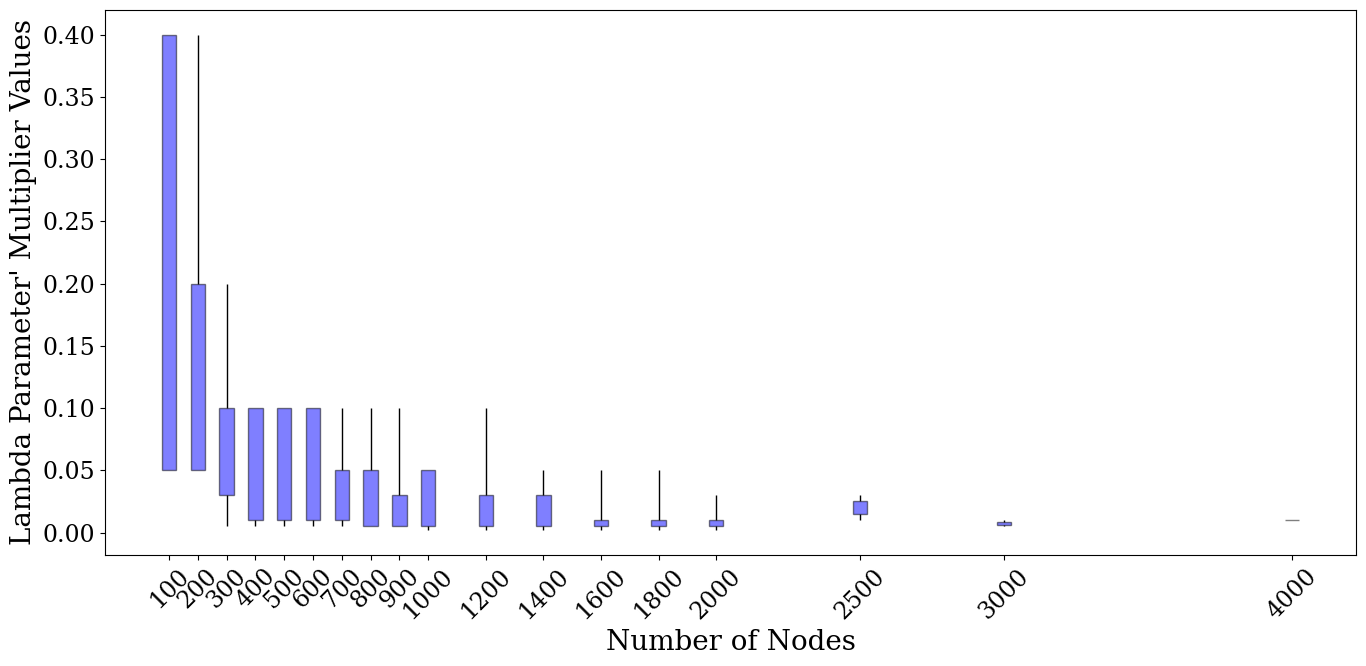

In [6]:
# Sample DataFrame (replace this with your actual `df_for_regression`)
candlestick_data = df_for_regression.groupby('nr_of_nodes').agg(
    gamma_min=('min_lambda_mult', list),
    gamma_max=('max_lambda_mult', list)
).reset_index()

# Prepare data for candlesticks
box_data = []
for _, row in candlestick_data.iterrows():
    gamma_min_values = sorted(row['gamma_min'])
    gamma_max_values = sorted(row['gamma_max'])
    
    # Compute quartiles for gamma_min and gamma_max
    q1_min, q3_min = np.percentile(gamma_min_values, [25, 75])
    q1_max, q3_max = np.percentile(gamma_max_values, [25, 75])
    
    # Compute whiskers (min and max values)
    whisker_min = min(gamma_min_values)
    whisker_max = max(gamma_max_values)
    
    # Append calculated values
    box_data.append({
        'nr_of_nodes': row['nr_of_nodes'],
        'q1_min': q1_min,
        'q3_min': q3_min,
        'q1_max': q1_max,
        'q3_max': q3_max,
        'whisker_min': whisker_min,
        'whisker_max': whisker_max
    })

# Convert back to a DataFrame for plotting
box_data = pd.DataFrame(box_data)

# Plot
plt.figure(figsize=(14, 7))

for _, row in box_data.iterrows():
    # Plot whiskers (lines)
    plt.vlines(
        x=row['nr_of_nodes'],
        ymin=row['whisker_min'],
        ymax=row['q1_min'],
        color='black', linewidth=1  # Bottom whisker
    )
    plt.vlines(
        x=row['nr_of_nodes'],
        ymin=row['q3_max'],
        ymax=row['whisker_max'],
        color='black', linewidth=1  # Top whisker
    )
    
    # Plot the box (rectangle)
    plt.bar(
        x=row['nr_of_nodes'],
        height=row['q3_max'] - row['q1_min'],
        bottom=row['q1_min'],
        width=50,  # Adjust width as necessary
        color='blue',
        alpha=0.5,
        edgecolor='black'
    )

# Customize plot
#plt.title('Gamma coeficient multiplier ranges based on number of nodes', fontsize=16)
plt.xlabel('Number of Nodes')
plt.ylabel('Lambda Parameter\' Multiplier Values')
plt.xticks(box_data['nr_of_nodes'], rotation = 45)
#plt.grid(alpha=0.3)
plt.tight_layout()

# Show plot
plt.show()


In [7]:

def read_sql(filename):
    # Define the folder containing SQL files
    # sql/ lives at the repository root; this notebook lives in src/
    sql_folder = os.path.join(os.path.dirname(os.path.abspath("")), "sql")
    filename+=".sql"
    file_path = os.path.join(sql_folder, filename)
    with open(file_path, "r", encoding="utf-8") as file:
        sql_query = file.read()
        #Execute query and load result into a Pandas DataFrame
        try:
            df = pd.read_sql_query(sql_query, con=engine)
            #print(f"Data from {filename}:")
            #print(df.head())  # Show first few rows
            return df
        except Exception as e:
            print(f"Error executing {filename}: {e}")

In [8]:


def plot_percent_stacked_bar(df, filter_column, filter_value, columns_to_plot, 
                             category_column=None, colormap='viridis', 
                             label_fontsize=10, legend_location='best', 
                             custom_labels=None,plot_title=None):
    """
    Plots a percent-stacked bar chart for given columns in a filtered DataFrame with customizable labels.

    Parameters:
    - df (pd.DataFrame): The input DataFrame.
    - filter_column (str): The column name to filter the DataFrame.
    - filter_value (str or int): The value to filter in the filter_column.
    - columns_to_plot (list): List of three column names to be plotted (must sum to 100% per row).
    - category_column (str, optional): Column used as x-axis labels (if None, index is used).
    - colormap (str): Matplotlib colormap for bar colors (default='viridis').
    - label_fontsize (int): Font size of percentage labels inside bars (default=10).
    - legend_location (str): Legend position (default='best').
    - custom_labels (dict): Dictionary for renaming column names in the legend and x-axis.

    Returns:
    - Displays a percent-stacked bar chart with customized labels.
    """
    
    # Filter DataFrame and reset index
    df_filtered = df[df[filter_column] == filter_value].reset_index(drop=True)

    # Select only the three specific columns
    df_percent = df_filtered[columns_to_plot]

    # Normalize each row to sum to 100%
    df_percent = df_percent.div(df_percent.sum(axis=1), axis=0) * 100

    # Apply custom labels (if provided)
    if custom_labels:
        legend_labels = [custom_labels.get(col, col) for col in columns_to_plot]
        x_labels = [custom_labels.get(cat, cat) for cat in df_filtered[category_column]] if category_column else None
    else:
        legend_labels = columns_to_plot
        x_labels = df_filtered[category_column] if category_column else None




    # Plot percent stacked bar chart
    ax = df_percent.plot(kind='bar', stacked=True, figsize=(10, 6), colormap=colormap)

    # Customize labels
    plt.xlabel(custom_labels.get(category_column, category_column) if category_column else 'Index')
    plt.ylabel('Percentage')
    # Set custom title if provided, otherwise default title
    plt.title(plot_title if plot_title else f'Percent Stacked Bar Plot (Filtered: {filter_value})')
    
    # Use category_column as x-axis labels if provided
    if category_column:
        plt.xticks(ticks=range(len(df_filtered)), labels=x_labels, rotation=45)
    else:
        plt.xticks(ticks=range(len(df_filtered)), labels=df_filtered.index, rotation=0)

    # Add labels to each segment
    for i, bars in enumerate(ax.containers):
        for bar in bars:
            height = bar.get_height()
            if height > 2:  # Only label if the segment is large enough to avoid clutter
                ax.text(bar.get_x() + bar.get_width() / 2, 
                        bar.get_y() + height / 2, 
                        f'{height:.1f}%', 
                        ha='center', va='center', fontsize=label_fontsize, 
                        color='white', fontweight='bold')

    # Add legend with custom names
    plt.legend(legend_labels, title='Columns', loc=legend_location)

    # Show plot
    plt.show()




In [9]:
import matplotlib.colors as mcolors
def create_custom_colormap(colors):
    """
    Creates a custom colormap from a list of colors.

    Parameters:
    - colors (list): A list of color names or hex codes.

    Returns:
    - A Matplotlib colormap object.
    """
    return mcolors.LinearSegmentedColormap.from_list("custom_colormap", colors)

# Define your custom colors (Hex or Named Colors)
custom_colors = ['#7870EB','#000066','#660066','#EF1355']

# Create a custom colormap
custom_colormap = create_custom_colormap(custom_colors)

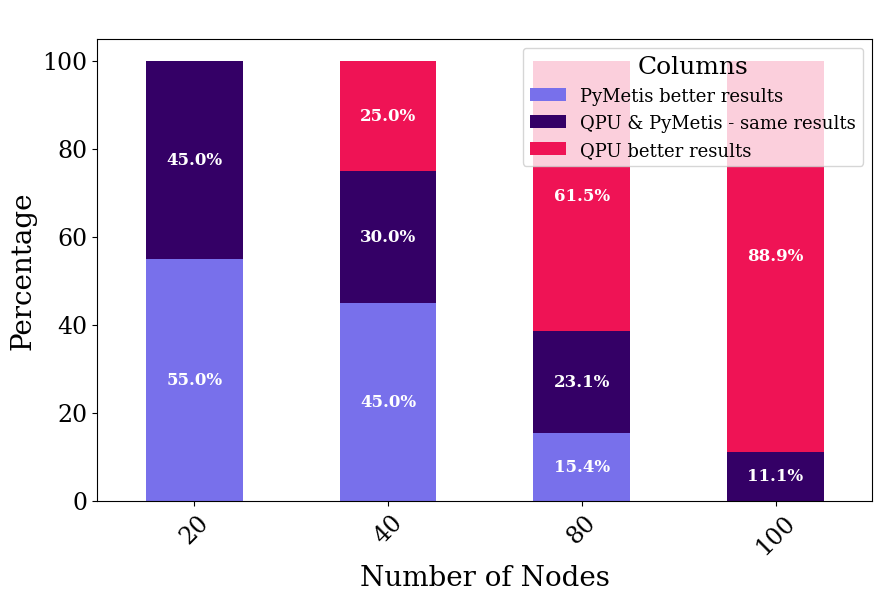

In [10]:
df_qpu_test = read_sql('qpu_test')
df_qpu_test['filter'] = df_qpu_test['nr_of_nodes'].isin([20,40,80,100]).astype(int)
custom_labels = {
    'pymetis_better_wocorrect': 'PyMetis better results',
    'qpu_better_wocorrect': 'QPU better results',
    'qpu_eq_pymetis_wocorrect': 'QPU & PyMetis - same results',
    'nr_of_nodes': 'Number of Nodes'
}


plot_percent_stacked_bar(df_qpu_test, filter_column='filter', filter_value=1, 
                         columns_to_plot=['pymetis_better_wocorrect','qpu_eq_pymetis_wocorrect',  'qpu_better_wocorrect'], 
                         category_column='nr_of_nodes',
                         colormap=custom_colormap, label_fontsize=12, legend_location='upper right',custom_labels=custom_labels,
                         plot_title=' ')

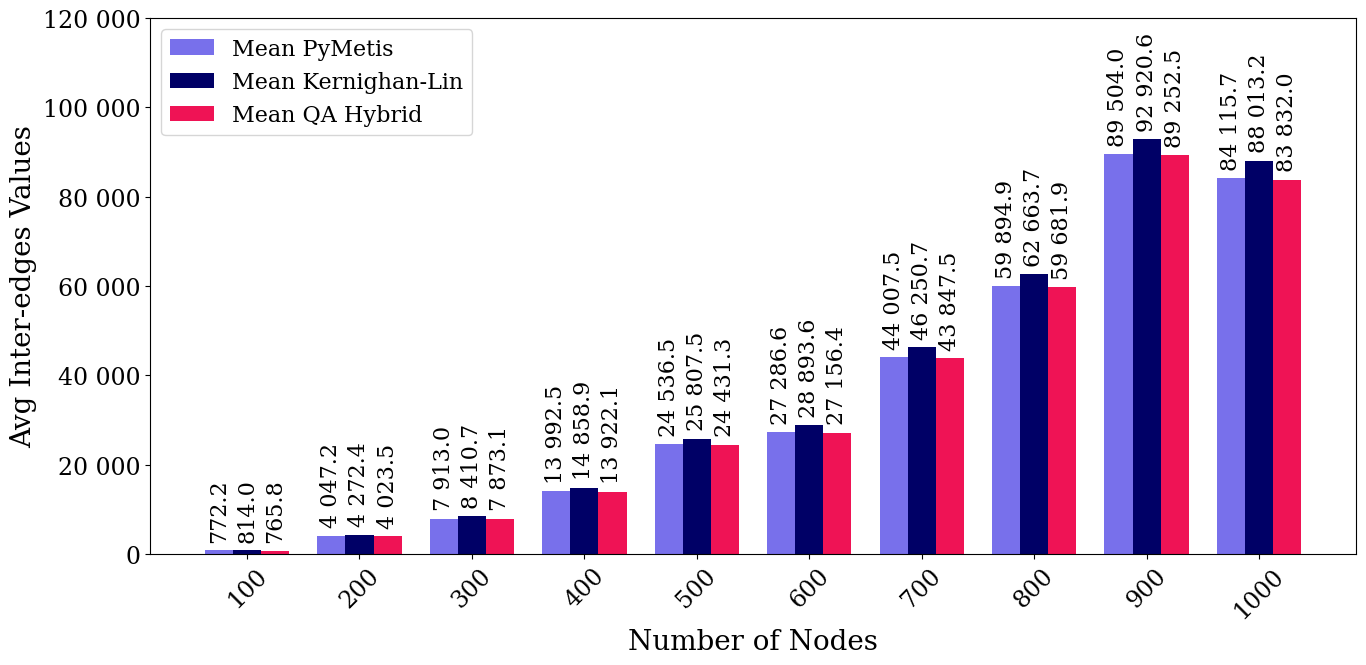

In [11]:
#custom_colors = ['#7870EB','#000066','#660066','#EF1355']    
df_kl_pm_qa = read_sql('kl_pm_qa_before_reg')

# Define custom colors
custom_colors = ['#7870EB', '#000066', '#EF1355']

# Create a figure and axes
fig, ax = plt.subplots(figsize=(14, 7))

bar_width = 0.25
indices = np.arange(len(df_kl_pm_qa['nr_of_nodes']))

# Bar plot for `avg_pymetis_inter_edges`
ax.bar(indices - bar_width, df_kl_pm_qa['avg_pymetis_inter_edges'], 
       color=custom_colors[0], width=bar_width, label='Mean PyMetis')

# Bar plot for `avg_KL_inter_edges`
ax.bar(indices, df_kl_pm_qa['avg_KL_inter_edges'], 
       color=custom_colors[1], width=bar_width, label='Mean Kernighan-Lin')

# Bar plot for `avg_qa_hybrid_inter_edges`
ax.bar(indices + bar_width, df_kl_pm_qa['avg_qa_hybrid_inter_edges'], 
       color=custom_colors[2], width=bar_width, label='Mean QA Hybrid')

# Add value labels inside the bars

# Add value labels inside the bars with better visibility
for i in range(len(df_kl_pm_qa['nr_of_nodes'])):
    ax.text(indices[i] - bar_width, df_kl_pm_qa['avg_pymetis_inter_edges'][i] + 3000, 
            f"{df_kl_pm_qa['avg_pymetis_inter_edges'][i]:,.1f}".replace(",", " "), 
            ha='center', color='black', fontsize=16,  rotation=90)

    ax.text(indices[i], df_kl_pm_qa['avg_KL_inter_edges'][i]  + 3000, 
            f"{df_kl_pm_qa['avg_KL_inter_edges'][i]:,.1f}".replace(",", " "), 
            ha='center', color='black', fontsize=16,  rotation=90)

    ax.text(indices[i] + bar_width, df_kl_pm_qa['avg_qa_hybrid_inter_edges'][i]  + 3000, 
            f"{df_kl_pm_qa['avg_qa_hybrid_inter_edges'][i]:,.1f}".replace(",", " "), 
            ha='center', color='black', fontsize=16,  rotation=90)

# Set axis labels
ax.set_xlabel('Number of Nodes')
ax.set_ylabel('Avg Inter-edges Values')

# Set y-axis ticks and format labels
ax.set_yticks([0, 20000, 40000, 60000, 80000, 100000, 120000])
ax.set_yticklabels(["0", "20 000", "40 000", "60 000", "80 000", "100 000", "120 000"])

# Set x-axis scale with all values explicitly listed
ax.set_xticks(indices)
ax.set_xticklabels(df_kl_pm_qa['nr_of_nodes'])

# Add legend
ax.legend(fontsize = 16)

# Add a title
plt.title('')
plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()
plt.show()


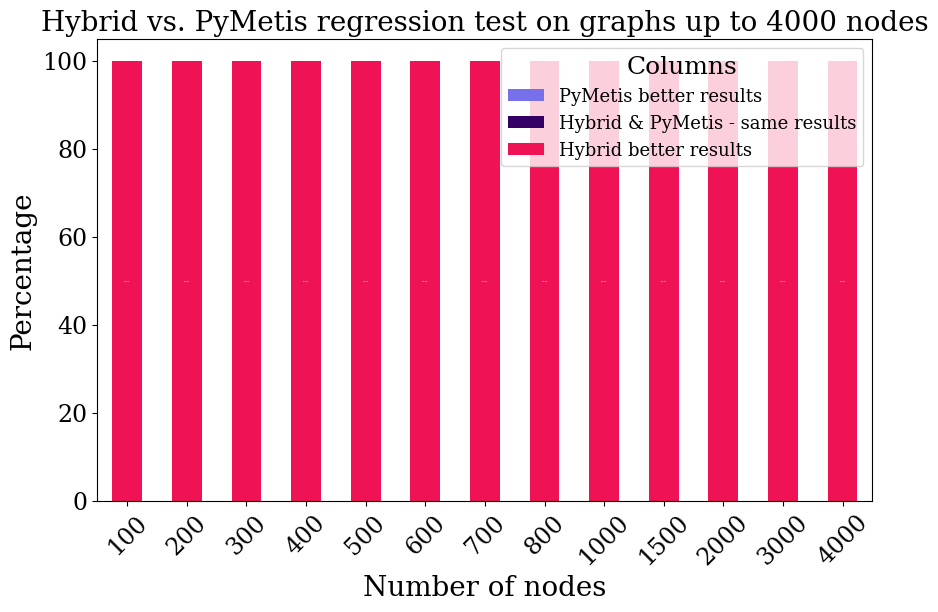

In [12]:
df_regression_test = read_sql('regression_test')
df_regression_test['filter'] = df_regression_test['nr_of_nodes'].isin([100,200,300,400,500,600,700,800,900,1000,1500,2000,2500,3000,4000]).astype(int)
custom_labels = {
    'pymetis_better_wocorrect': 'PyMetis better results',
    'hybrid_better_wocorrect': 'Hybrid better results',
    'hybrid_eq_pymetis_wocorrect': 'Hybrid & PyMetis - same results',
    'nr_of_nodes': 'Number of nodes'
}
plot_percent_stacked_bar(df_regression_test, filter_column='filter', filter_value=1, 
                         columns_to_plot=['pymetis_better_wocorrect','hybrid_eq_pymetis_wocorrect',  'hybrid_better_wocorrect'], 
                         category_column='nr_of_nodes',
                         colormap=custom_colormap, label_fontsize = 0, legend_location='upper right',custom_labels=custom_labels,
                         plot_title='Hybrid vs. PyMetis regression test on graphs up to 4000 nodes')

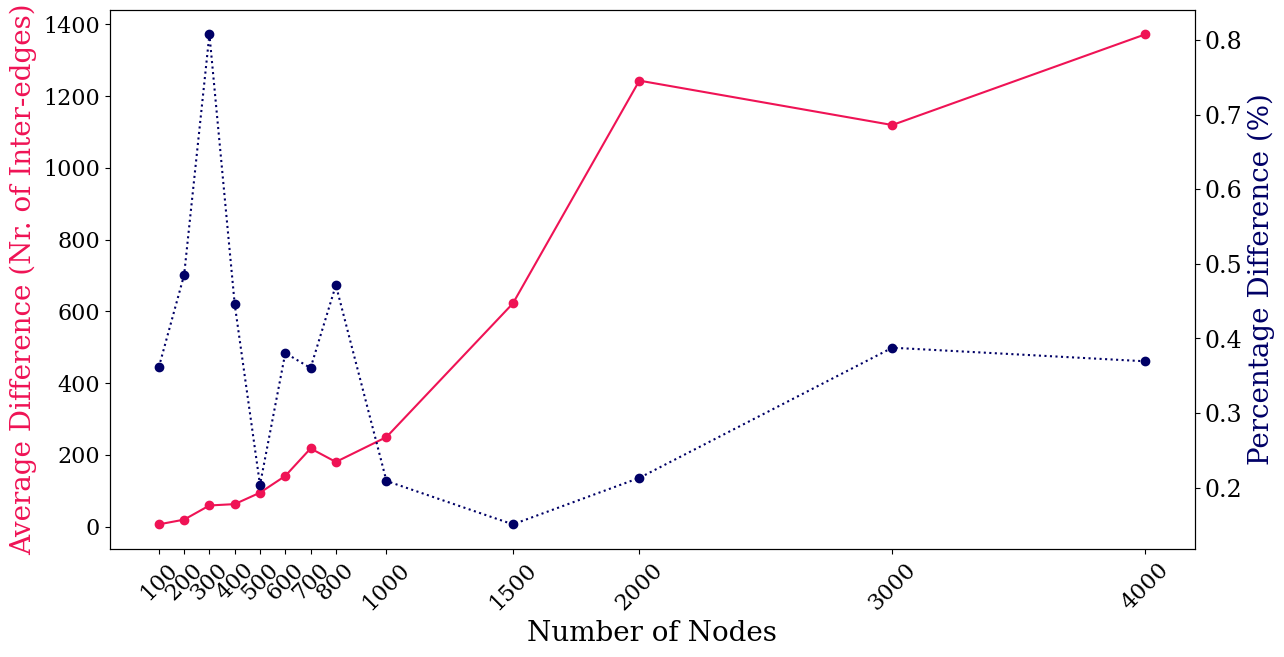

In [13]:
import matplotlib.pyplot as plt

# Load the dataset
df_regression_comparision = read_sql('regression_test')

# Aggregate the data
result = df_regression_comparision.groupby('nr_of_nodes').agg(
    absolute_diff=('absolute_difference', 'mean'),
    percentage_diff=('percentage_difference', 'mean')
).reset_index()

# Create figure and axis
fig, ax1 = plt.subplots(figsize=(14, 7))

# Primary axis (absolute difference)
ax1.set_xlabel("Number of Nodes", fontsize=20)
ax1.set_ylabel("Average Difference (Nr. of Inter-edges)", color="#EF1355", fontsize=20)
ax1.plot(result["nr_of_nodes"], result["absolute_diff"], marker="o", linestyle="-", label="Average Difference", color='#EF1355')

# Secondary axis (percentage difference)
ax2 = ax1.twinx()
ax2.set_ylabel("Percentage Difference (%)", color="#000066", fontsize=20)
ax2.plot(result["nr_of_nodes"], result["percentage_diff"], marker="o", linestyle=":", label="Percentage Difference", color="#000066")
ax2.tick_params(axis="y", labelcolor='black', labelsize=17)

# Rotate x-axis labels
ax1.set_xticks(result["nr_of_nodes"])  # Ensure all x-ticks are properly aligned
ax1.set_xticklabels(result["nr_of_nodes"], rotation=45, fontsize=17)

# Adjust other tick sizes
ax1.tick_params(axis="y", labelsize=16)
ax1.tick_params(axis="x", labelsize=16)

# Title (if needed)
plt.title('', fontsize=20)

# Show the plot
plt.show()


In [14]:
df_before_regression_heat = read_sql('before_regression_heat')

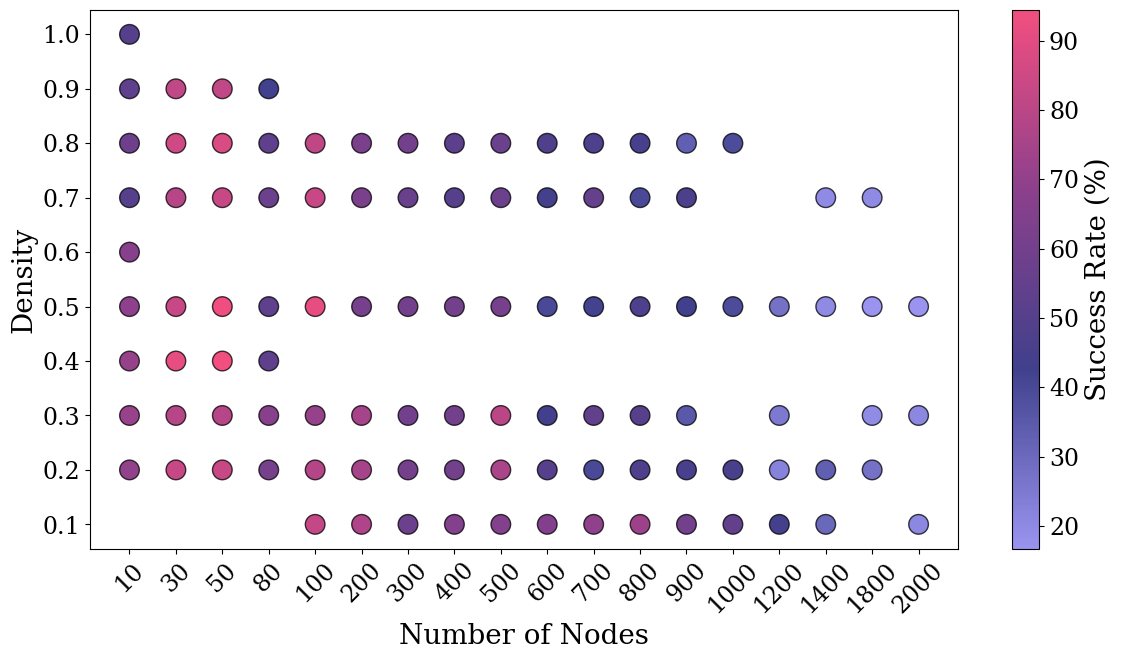

In [15]:
# Get unique values for proper placement
x_labels = sorted(df_before_regression_heat['nr_of_nodes'].unique())
y_labels = sorted(df_before_regression_heat['density'].unique())

# Create meshgrid for placement
x_positions = [x_labels.index(x) for x in df_before_regression_heat['nr_of_nodes']]
y_positions = [y_labels.index(y) for y in df_before_regression_heat['density']]

# Create scatter plot with circular markers
#plt.figure(figsize=(6, 4))
plt.scatter(x_positions, y_positions, s=200, c=df_before_regression_heat['success_rate']*100, cmap=custom_colormap, alpha=0.75, marker="o", edgecolors="black")

# Format axes
plt.xticks(ticks=range(len(x_labels)), labels=x_labels, rotation=45)
plt.yticks(ticks=range(len(y_labels)), labels=y_labels)
plt.colorbar(label="Success Rate (%)")
plt.xlabel("Number of Nodes")
plt.ylabel("Density")
plt.title('')

plt.show()

Sample 1: Predicted Interval = (np.float64(0.007944124188659566), np.float64(0.008061336438946617))
Sample 2: Predicted Interval = (np.float64(0.01394424198269185), np.float64(0.0400655625226286))
Sample 3: Predicted Interval = (np.float64(0.008496906537862852), np.float64(0.023931961239700924))
Sample 4: Predicted Interval = (np.float64(0.017681473512844607), np.float64(0.03699500193280576))
Sample 5: Predicted Interval = (np.float64(0.023927243031264714), np.float64(0.08458843693287817))
Sample 6: Predicted Interval = (np.float64(0.058778253602591445), np.float64(0.399620656777421))
Sample 7: Predicted Interval = (np.float64(0.015754202151122887), np.float64(0.029882860750282507))
Sample 8: Predicted Interval = (np.float64(0.02568308585269128), np.float64(0.09972311427787015))
Sample 9: Predicted Interval = (np.float64(0.013876987707303232), np.float64(0.017293890718688913))
Sample 10: Predicted Interval = (np.float64(0.016768511386003104), np.float64(0.06541820833474256))
Sample 11:

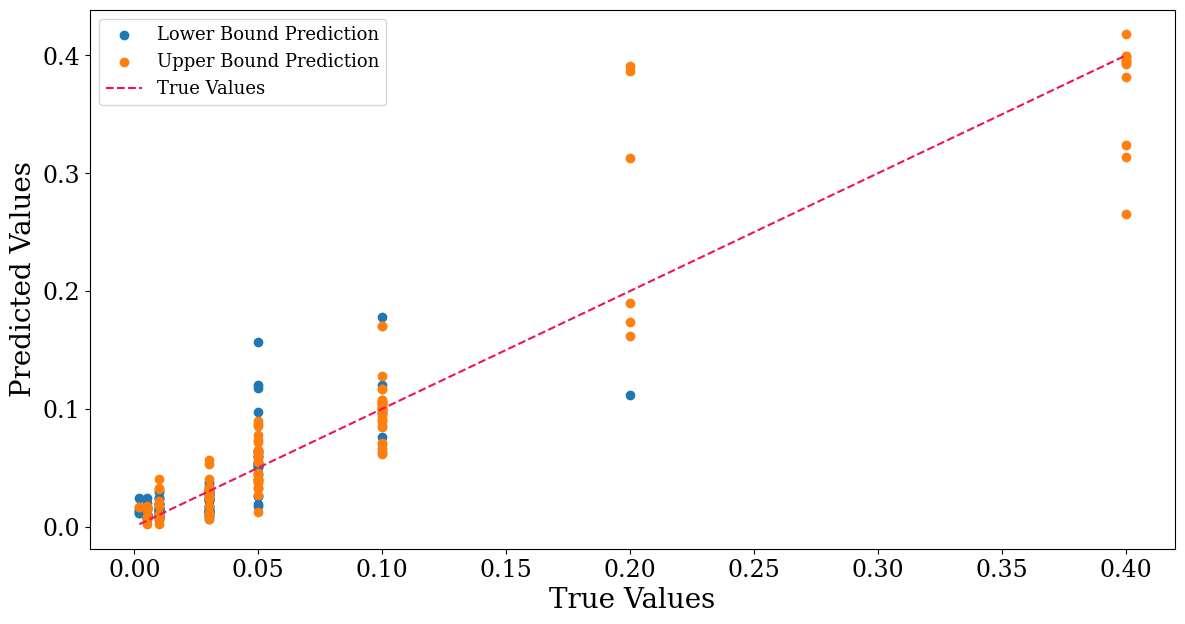

In [16]:
# Separate predictors (X) and targets (y)
X = df_for_regression[['density', 'nr_of_nodes','lambda_est']]
y_min = df_for_regression['min_lambda_mult']
y_max = df_for_regression['max_lambda_mult']

# Split data into training and testing sets
X_train, X_test, y_min_train, y_min_test, y_max_train, y_max_test = train_test_split(
    X, y_min, y_max, test_size=0.2, random_state=42
)

# Initialize Gradient Boosting Regressors
gbr_min = GradientBoostingRegressor(random_state=42)
gbr_max = GradientBoostingRegressor(random_state=42)

# Fit the models
gbr_min.fit(X_train, y_min_train)
gbr_max.fit(X_train, y_max_train)

# Predict intervals
y_min_pred = gbr_min.predict(X_test)
y_max_pred = gbr_max.predict(X_test)

# Combine predictions into an interval
predicted_intervals = list(zip(y_min_pred, y_max_pred))

# Display results
for i, interval in enumerate(predicted_intervals):
    print(f"Sample {i + 1}: Predicted Interval = {interval}")

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# Evaluate for min_value
mse_min = mean_squared_error(y_min_test, y_min_pred)
mae_min = mean_absolute_error(y_min_test, y_min_pred)
rmse_min = np.sqrt(mse_min)
r2_min = r2_score(y_min_test, y_min_pred)

print(f"--- min_lambda_mult ---")
print(f"MAE:  {mae_min:.4f}")
print(f"MSE:  {mse_min:.4f}")
print(f"RMSE: {rmse_min:.4f}")
print(f"R²:   {r2_min:.4f}\n")

# Evaluate for max_value
mse_max = mean_squared_error(y_max_test, y_max_pred)
mae_max = mean_absolute_error(y_max_test, y_max_pred)
rmse_max = np.sqrt(mse_max)
r2_max = r2_score(y_max_test, y_max_pred)

print(f"--- max_lambda_mult ---")
print(f"MAE:  {mae_max:.4f}")
print(f"MSE:  {mse_max:.4f}")
print(f"RMSE: {rmse_max:.4f}")
print(f"R²:   {r2_max:.4f}")


import matplotlib.pyplot as plt

# Plot predicted intervals vs true values
plt.scatter(y_min_test, y_min_pred, label="Lower Bound Prediction")
plt.scatter(y_max_test, y_max_pred, label="Upper Bound Prediction")
plt.plot([min(y_min_test), max(y_max_test)], [min(y_min_test), max(y_max_test)], color='#EF1355', linestyle='--', label="True Values")
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.show()

Sample 1: Predicted Interval = (np.float64(0.007944124188659566), np.float64(0.008061336438946617))
Sample 2: Predicted Interval = (np.float64(0.01394424198269185), np.float64(0.0400655625226286))
Sample 3: Predicted Interval = (np.float64(0.008496906537862852), np.float64(0.023931961239700924))
Sample 4: Predicted Interval = (np.float64(0.017681473512844607), np.float64(0.03699500193280576))
Sample 5: Predicted Interval = (np.float64(0.023927243031264714), np.float64(0.08458843693287817))
Sample 6: Predicted Interval = (np.float64(0.058778253602591445), np.float64(0.399620656777421))
Sample 7: Predicted Interval = (np.float64(0.015754202151122887), np.float64(0.029882860750282507))
Sample 8: Predicted Interval = (np.float64(0.02568308585269128), np.float64(0.09972311427787015))
Sample 9: Predicted Interval = (np.float64(0.013876987707303232), np.float64(0.017293890718688913))
Sample 10: Predicted Interval = (np.float64(0.016768511386003104), np.float64(0.06541820833474256))
Sample 11:

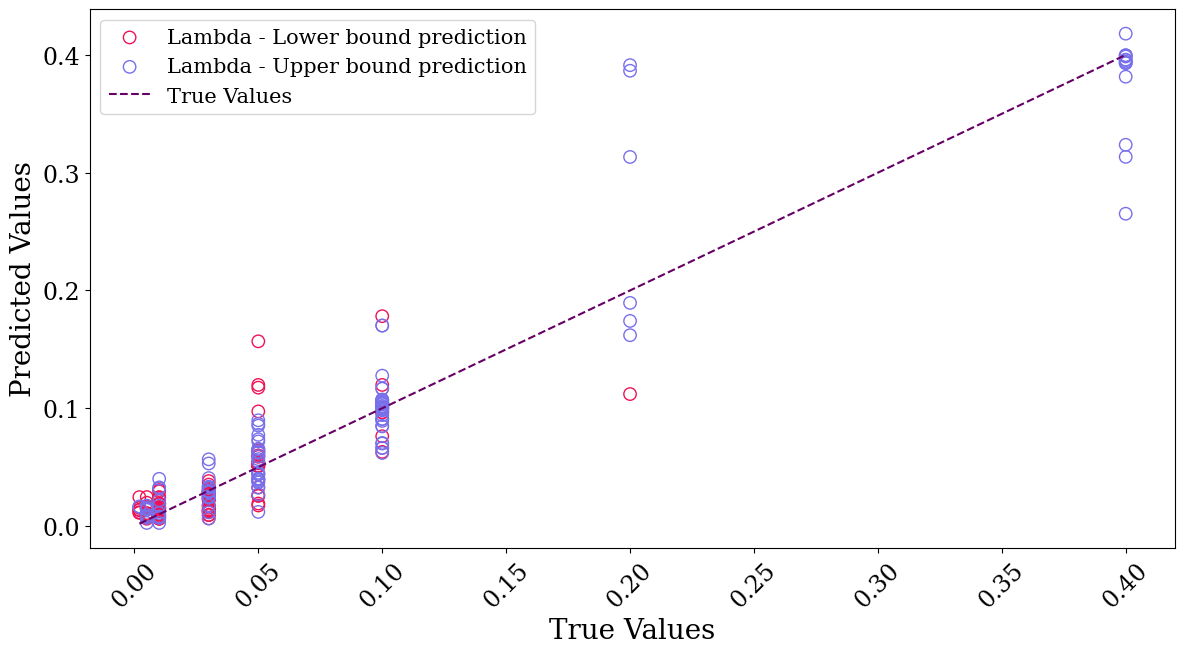

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

# Separate predictors (X) and targets (y)
X = df_for_regression[['density', 'nr_of_nodes','lambda_est']]
y_min = df_for_regression['min_lambda_mult']
y_max = df_for_regression['max_lambda_mult']

# Split data into training and testing sets
X_train, X_test, y_min_train, y_min_test, y_max_train, y_max_test = train_test_split(
    X, y_min, y_max, test_size=0.2, random_state=42
)

# Initialize Gradient Boosting Regressors
gbr_min = GradientBoostingRegressor(random_state=42)
gbr_max = GradientBoostingRegressor(random_state=42)

# Fit the models
gbr_min.fit(X_train, y_min_train)
gbr_max.fit(X_train, y_max_train)

# Predict intervals
y_min_pred = gbr_min.predict(X_test)
y_max_pred = gbr_max.predict(X_test)

# Combine predictions into an interval
predicted_intervals = list(zip(y_min_pred, y_max_pred))

# Display results
for i, interval in enumerate(predicted_intervals):
    print(f"Sample {i + 1}: Predicted Interval = {interval}")

# Evaluate for min_value
mse_min = mean_squared_error(y_min_test, y_min_pred)
print(f"Mean Squared Error for min_value: {mse_min}")

# Evaluate for max_value
mse_max = mean_squared_error(y_max_test, y_max_pred)
print(f"Mean Squared Error for max_value: {mse_max}")

# Plot predicted intervals vs true values
plt.figure(figsize=(14, 7))
plt.scatter(y_min_test, y_min_pred, color='#EF1355', facecolors='none', s=80, label="Lambda - Lower bound prediction")
plt.scatter(y_max_test, y_max_pred, color='#7870EB', facecolors='none', s=80,  label="Lambda - Upper bound prediction")
plt.plot([min(y_min_test), max(y_max_test)], [min(y_min_test), max(y_max_test)], color='#660066', linestyle='--', label="True Values")
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.legend(fontsize = 15)
plt.xticks(rotation =45)
plt.show()